In [ ]:
import numpy as np                # Numerical programming package
import matplotlib.pyplot as plt   # Plotting library
import scipy as sci               # Scientific computing library
import numba as nb                # Just-In-Time (JIT) compiler
import timeit                     # Library to time small bits of code

# Exercise 1: compute the numerical derivative of a function

The derivative of a function $ \dfrac{df}{dx}  $ can be approximated with finite differences.

In particular, for first-order derivatives we have:

- The forward finite difference approximation:
$  \dfrac{df}{dx} \approx \dfrac{f_{n+1} - f_{n}}{\Delta x} $

- The backward finite difference approximation:
$  \dfrac{df}{dx} \approx \dfrac{f_{n} - f_{n-1}}{\Delta x} $

- The centered finite difference approximation:
$  \dfrac{df}{dx} \approx \dfrac{f_{n+1} - f_{n-1}}{2 \Delta x} $


Implement the three python functions below to compute finite difference approximations of derivatives, by adding the missing code in `forward_first_order_derivative`, `backward_first_order_derivative`, and `centered_first_order_derivative`. Then, run the `do_first_order_test_derivative` and observe how the error decreases. Note: we don't care much about performances in this exercise, so feel free to use python loops to compute these derivatives.

In [ ]:
def forward_first_order_derivative (f, delta_x):
    """
    Computes the forward first order approximation of the derivative of a function.
    Note that if the function is known at point i = 0...(N-1), the derivative is
    computed at points i = 0...(N-2) and set to 0 at point i = N-1

    Parameters
    ----------
    f : array of floats
        Values of the function to be derived
    dx : float
        Size of the spatial step

    Returns
    -------
    result : array of floats
        Values of the forward first order approximation of the derivative of f

    """
    N = len(f)
    result = np.zeros(N)

    ### ADD YOUR CODE HERE ####
    # for i in range(N-1):
    #     result[i] = ?
    ### ADD YOUR CODE HERE ####

    #######SOLUTION############
    for i in range(N-1):
        result[i] = (f[i+1] - f[i])/delta_x
    ###########################

    return result


def backward_first_order_derivative (f, delta_x):
    """
    Computes the backward first order approximation of the derivative of a function.
    Note that if the function is known at point i = 0...(N-1), the derivative is
    computed at points i = 1...(N-1) and set to 0 at point i = 0.

    Parameters
    ----------
    f : array of floats
        Values of the function to be derived
    dx : float
        Size of the spatial step

    Returns
    -------
    result : array of floats
        Values of the backward first order approximation of the derivative of f

    """

    N = len(f)
    result = np.zeros(N)

    ### ADD YOUR CODE HERE ####
    # for i in range(1,N):
    #     result[i] = ?
    ### ADD YOUR CODE HERE ####

    #######SOLUTION############
    for i in range(1,N):
        result[i] = (f[i]-f[i-1])/delta_x
    ###########################

    return result


def centered_first_order_derivative (f, delta_x):
    """
    Computes the centered first order approximation of the derivative of a function.
    Note that if the function is known at point i = 0...(N-1), the derivative is
    computed at points i = 1...(N-2) and set to 0 at points i = 0 and i = N-1.

    Parameters
    ----------
    f : array of floats
        Values of the function to be derived
    dx : float
        Size of the spatial step

    Returns
    -------
    result : array of floats
        Values of the centered first order approximation of the derivative of f

    """

    N = len(f)
    result = np.zeros(N)

    ### ADD YOUR CODE HERE ####
    # for i in range(1,N-1):
    #     result[i] = ?
    ### ADD YOUR CODE HERE ####

    #######SOLUTION############
    for i in range(1,N-1):
        result[i] = 0.5*(f[i+1]-f[i-1])/delta_x
    ###########################

    return result

Python tip: if you write a comment between triple double quotes at the beginning of a function (e.g.,  `""" COMMENT """`), it is treated as a docstring and it shows up with the command `help`:

In [ ]:
help(backward_first_order_derivative)

Help on function backward_first_order_derivative in module __main__:

backward_first_order_derivative(f, delta_x)
    Computes the backward first order approximation of the derivative of a function.
    Note that if the function is known at point i = 0...(N-1), the derivative is
    computed at points i = 1...(N-1) and set to 0 at point i = 0.
    
    Parameters
    ----------
    f : array of floats
        Values of the function to be derived
    dx : float
        Size of the spatial step
    
    Returns
    -------
    result : array of floats
        Values of the backward first order approximation of the derivative of f



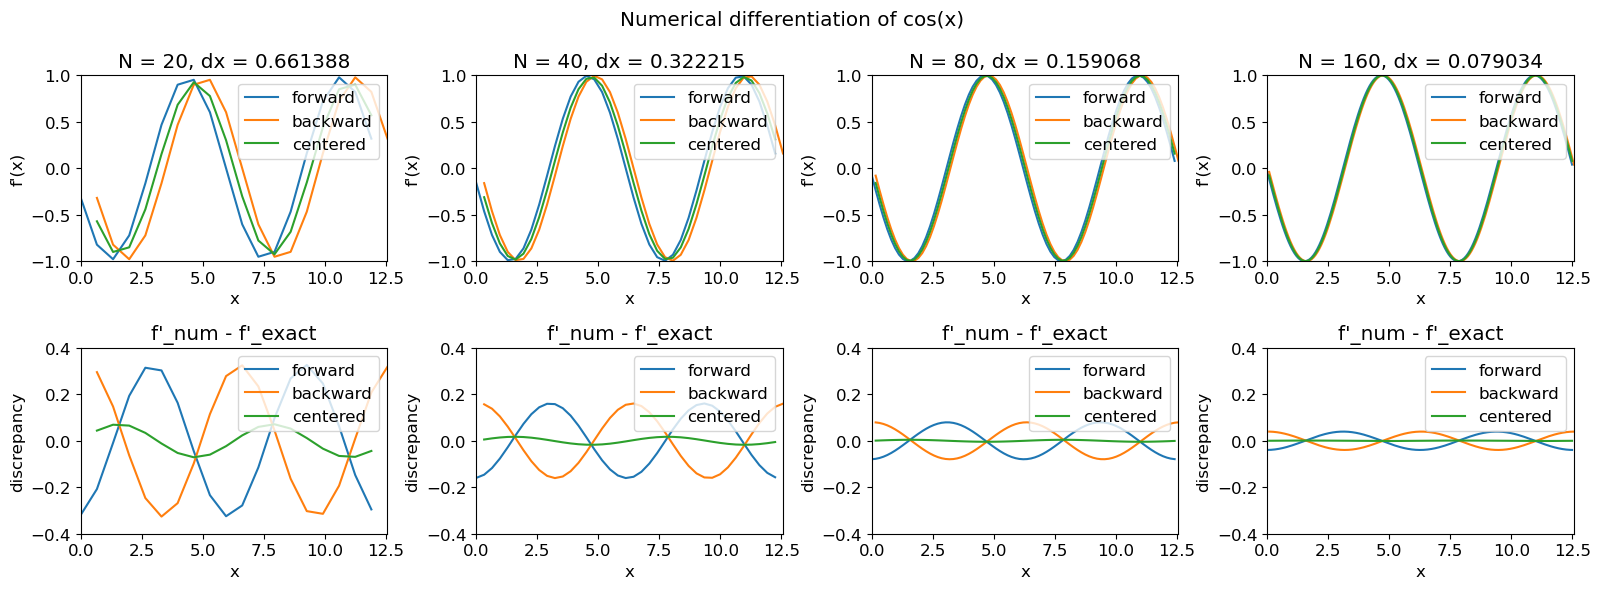

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def do_first_order_derivative_test ():
    """
    Test the functions that compute first order derivatives with various finite difference schemes.
    """

    plt.rcParams['font.size'] = 12
    fig, ax = plt.subplots(2,4,figsize=(16,6))

    Ns = [20,40,80,160]

    for i, N in enumerate(Ns):

        L = 4.0*np.pi
        xx = np.linspace(0, 4.0*np.pi, N)
        dx = L/(N-1)

        f = np.cos(xx)
        fp = -np.sin(xx)

        fwd_first_order = forward_first_order_derivative(f, dx)
        bwd_first_order = backward_first_order_derivative(f, dx)
        cen_first_order = centered_first_order_derivative(f, dx)

        fig.suptitle("Numerical differentiation of cos(x)")

        ax[0,i].set_title("N = {:}, dx = {:f}".format(N, dx))

        ax[0,i].set_xlabel("x")
        ax[0,i].set_ylabel("f'(x)")

        ax[0,i].set_xlim(0,L)
        ax[0,i].set_ylim(-1.0,1.0)

        ax[0,i].plot(xx[:-1], fwd_first_order[:-1], color="tab:blue", label='forward')
        ax[0,i].plot(xx[1:], bwd_first_order[1:], color="tab:orange", label='backward')
        ax[0,i].plot(xx[1:-1], cen_first_order[1:-1], color="tab:green", label='centered')

        ax[0,i].legend(loc='upper right')

        ax[1,i].set_title("f'_num - f'_exact")

        ax[1,i].set_xlabel("x")
        ax[1,i].set_ylabel("discrepancy")

        ax[1,i].set_xlim(0,L)
        #ax[1,i].set_ylim(-0.4/(i+1),0.4/(i+1))
        ax[1,i].set_ylim(-0.4,0.4)

        ax[1,i].plot(xx[:-1], fwd_first_order[:-1] - fp[:-1], color="tab:blue", label='forward')
        ax[1,i].plot(xx[1:], bwd_first_order[1:] - fp[1:], color="tab:orange", label='backward')
        ax[1,i].plot(xx[1:-1], cen_first_order[1:-1] - fp[1:-1], color="tab:green", label='centered')

        ax[1,i].legend(loc='upper right')

    plt.tight_layout()

do_first_order_derivative_test()

Run also the following block of code, that computes the numerical derivate of $\exp(x)$ in $x = 0$ and plots the error. Can you explain the result?

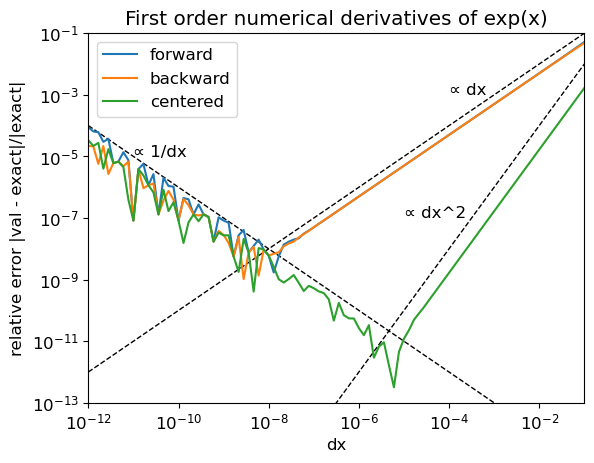

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def do_first_order_derivative_error_test():
    """
    Test the error introduced by the functions that compute first order derivatives
    as a function of the spatial step size
    """

    N = 100

    dxs = np.logspace(-12, -1, N)

    exact = 1.0
    x0 = 0

    df_forward = np.zeros(N)
    df_backward = np.zeros(N)
    df_centered = np.zeros(N)

    for i, dx in enumerate(dxs):
        xs = np.array([x0-dx, x0, x0+dx])
        f_vals = np.exp(xs)
        df_forward[i] = forward_first_order_derivative(f_vals, dx)[1]
        df_backward[i] = backward_first_order_derivative(f_vals, dx)[1]
        df_centered[i] = centered_first_order_derivative(f_vals, dx)[1]

    plt.rcParams['font.size'] = 12
    fig, ax = plt.subplots(1,1)

    ax.loglog(dxs, 1e-16*dxs**-1,'--', c="black", linewidth=1)
    ax.loglog(dxs, dxs,'--', c="black", linewidth=1)
    ax.loglog(dxs, dxs**2,'--', c="black", linewidth=1)

    ax.loglog(dxs, np.abs(df_forward-exact)/np.abs(exact), label="forward")
    ax.loglog(dxs, np.abs(df_backward-exact)/np.abs(exact), label="backward")
    ax.loglog(dxs, np.abs(df_centered-exact)/np.abs(exact), label="centered")

    ax.text(1e-11, 1e-5, '∝ 1/dx')
    ax.text(1e-4, 1e-3, '∝ dx')
    ax.text(1e-5, 1e-7, '∝ dx^2')

    ax.set_title("First order numerical derivatives of exp(x)")
    ax.set_xlabel("dx")
    ax.set_ylabel("relative error |val - exact|/|exact|")
    ax.legend()

    ax.set_xlim(1e-12, 1e-1)
    ax.set_ylim(1e-13, 1e-1)

do_first_order_derivative_error_test()

You can have a look at [this link](https://en.wikipedia.org/wiki/Numerical_differentiation#Step_size) for more details.

# Exercise 2: implement the Gauss-Seidel method

In this exercise you will implement the Gauss-Seidel method to iteratively solve a system of linear equations:

$ A \mathbf{x} = \mathbf{b} $

Remember that in the Gauss-Seidel method:

$ x^{(n+1)}_i = {\dfrac{1}{a_{ii}}} {\left(  { b_i - \sum_{j=1}^{i-1} a_{ij} x_j^{(n+1)} - \sum_{j=i+1}^{N} a_{ij} x_j^{(n)} } \right) } $

and that we can check if convergence is attained with the `residual`:

$ \| R \| < \epsilon$ where $ \| R \| = \sqrt{\sum_i R_i^2} $ and $ R =  A \mathbf{x}^{(n+1)} - \mathbf{b}  $

(use`A.dot(x)` to compute the matrix-vector product and `np.linalg.norm` to compute the norm of the residual).

Complete the `gauss_seidel` function below and test it by running the `do_gauss_seidel_test` function. The code is checked using the `np.linalg.solve` method in `numpy`, that solves a linear system "exactly" (under the hood, it used the `_gesv` routine implemented in LAPACK, as documented [here](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)).

Note that we don't care too much about performances in this exercise, so don't be afraid of using python loops.

Note also that the Gauss-Seidel method allows us to update $x$ in place, so $x^{(n+1)}$ and $x^{(x)}$ are actually the same numpy array.

In [ ]:
def gauss_seidel (A, b, x0, tolerance, max_iter):
    """
    This method solves the linear system Ax = b iteratively, starting from the initial guess x0,
    using the Gauss-Seidel method. The method stops if tolerance is met or if the max_iter number
    of iterations is attained (in this second case an error is thrown).

    Parameters
    ----------
    A : ndarray of floats
        NxN matrix, coefficient matrix of Ax=b
    b : array of floats
        vector of size N, right-hand side of Ax=b
    x0 : array of floats
        vector of size N, initial guess of the unknown in Ax=b
    tolerance : float
        maximum accepted value of the residual norm
    max_iter : integer
        maximum number of iterations

    Returns
    -------
    result : array of floats
        vector of size N, best estimation of the solution of Ax=b
    """

    N = np.shape(x0)[0] # size of the vectors x and b, and of the square matrix A

    x = np.copy(x0) # deep copy of the initial guess x0: we don't want to overwrite it!

    # residual R
    R = np.zeros(N)
    norm_R = 1.0

    for it in range(max_iter):
        #### YOUR CODE HERE ###
        # x = [...] ?
        #
        # R = ?
        # norm_R = ?
        #######################

        #### SOLUTION ###
        for i in range(N):
            temp = np.sum(A[i, 0:i]*x[0:i]) + np.sum(A[i, i+1:]*x[i+1:])
            x[i] = (b[i] - temp)/A[i,i]

        R = A.dot(x) - b

        norm_R = np.linalg.norm(R)
        ##################

        print ("Iteration: ", it,  "|R|:  ", norm_R,  "Tolerance:  ", tolerance)

        if (norm_R < tolerance):
            return x

    raise RuntimeError("Solver failed to converge!")

    return x

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def test_gauss_seidel ():
    """
    Test the Gauss-Seidel solver "gauss_seidel"
    """

    ####### TEST CASE Ax = b ########
    A = np.array([
        [7.0, 2.0, -3.0, 1.0],
        [-4.0, 8.0, 1.0, -2.0],
        [3.0, -2.0, 9.0, 2.0],
        [1.0, -1.0, 1.0, 4.0]])

    b = np.array([-1.0, 16.0, -3.0, 5.0])
    #################################

    x0 = np.array([0.0,0.0,0.0,0.0])
    tolerance = 1.0e-6
    max_iter = 50

    try:
        xs = gauss_seidel (A, b, x0, tolerance, max_iter)

        print("*************************************")
        print("* Your Gauss-Seidel solver has found this solution: ")
        print("*", xs)
        print("* The exact solution is: ")
        print("*",np.linalg.solve(A, b))
        print("*************************************")

    except Exception as error:

        print("Failure: ", error)

test_gauss_seidel ()

Iteration:  0 |R|:   7.047420464544572 Tolerance:   1e-06
Iteration:  1 |R|:   1.0254363444828667 Tolerance:   1e-06
Iteration:  2 |R|:   0.15558225165024578 Tolerance:   1e-06
Iteration:  3 |R|:   0.020376631455810573 Tolerance:   1e-06
Iteration:  4 |R|:   0.0035132499139394814 Tolerance:   1e-06
Iteration:  5 |R|:   0.00038111560735428146 Tolerance:   1e-06
Iteration:  6 |R|:   8.825641319781974e-05 Tolerance:   1e-06
Iteration:  7 |R|:   6.629602459656231e-06 Tolerance:   1e-06
Iteration:  8 |R|:   2.7656633503607105e-06 Tolerance:   1e-06
Iteration:  9 |R|:   2.743518941831631e-07 Tolerance:   1e-06
*************************************
* Your Gauss-Seidel solver has found this solution: 
* [-1.00000002e+00  1.99999998e+00  1.63199591e-08  2.00000000e+00]
* The exact solution is: 
* [-1.  2.  0.  2.]
*************************************


Note that we have used ` x = np.copy(x0)` in the previous exercise. Indeed, with numpy, `x = x0` would not make a copy of `x0`! This can be very tricky, as you can see by running the code below. You can have a look [here](https://zingale.github.io/computational_astrophysics/python/numpy-basics.html) for more details.

In [ ]:
# this is a numpy array
x = np.array([0,1,2,3,4,5])
print("x =", x, "\n")

# x1 here is just another name for x !
x1 = x
x1[1] = 7
print("x1 = x, x1[1] = 7 -> x =", x, "   x1 =", x1, "\n")

# xw here is a view, but still points to the same data !
xw = x[0:2]
xw[0] = -1
print("xw = x[0:2], xw[0] = -1 -> x =", x, "   xw =", xw, "\n")

# to get a deep copy we can use `.copy`:
xc = x.copy()
xc[0] = -99
print("xc = x.copy(), xc[0] = -99 -> x =", x, "   xc =", xc, "\n")

x = [0 1 2 3 4 5] 

x1 = x, x1[1] = 7 -> x = [0 7 2 3 4 5]    x1 = [0 7 2 3 4 5] 

xw = x[0:2], xw[0] = -1 -> x = [-1  7  2  3  4  5]    xw = [-1  7] 

xc = x.copy(), xc[0] = -99 -> x = [-1  7  2  3  4  5]    xc = [-99   7   2   3   4   5] 



# Exercise 3: use numba to generate a compiled version of the Gauss-Seidel method

Copy the code of the `gauss_seidel` function inside `gauss_seidel_compiled` and compile it using the `@nb.jit` decorator (have a look at the [Numba webpage](https://numba.readthedocs.io/en/stable/user/5minguide.html) for more details). Then, run the block of code below to check performances.

In [ ]:
#### YOUR CODE HERE ###

#@nb.jit
#def gauss_seidel_compiled (A, b, x0, tolerance, max_iter):
#    YOUR CODE FROM THE PREVIOUS EXERCISE

####

### SOLUTION
@nb.jit
def gauss_seidel_compiled (A, b, x0, tolerance, max_iter):
    """
    This method solves the linear system Ax = b iteratively, starting from the initial guess x0,
    using the Gauss-Seidel method. The method stops if tolerance is met or if the max_iter number
    of iterations is attained (in this second case an error is thrown).

    Parameters
    ----------
    A : ndarray of floats
        NxN matrix, coefficient matrix of Ax=b
    b : array of floats
        vector of size N, right-hand side of Ax=b
    x0 : array of floats
        vector of size N, initial guess of the unknown in Ax=b
    tolerance : float
        maximum accepted value of the residual norm
    max_iter : integer
        maximum number of iterations

    Returns
    -------
    result : array of floats
        vector of size N, best estimation of the solution of Ax=b
    """

    N = np.shape(x0)[0] # size of the vectors x and b, and of the square matrix A

    x = np.copy(x0) # deep copy of the initial guess x0: we don't want to overwrite it!

    # residual R
    R = np.zeros(N)
    norm_R = 1.0

    for it in range(max_iter):

        for i in range(N):
            temp = np.sum(A[i, 0:i]*x[0:i]) + np.sum(A[i, i+1:]*x[i+1:])
            x[i] = (b[i] - temp)/A[i,i]

        R = A.dot(x) - b

        norm_R = np.linalg.norm(R)

        print ("Iteration: ", it,  "|R|:  ", norm_R,  "Tolerance:  ", tolerance)

        if (norm_R < tolerance):
            return x

    raise RuntimeError("Solver failed to converge!")

    return x
###


In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def test_gauss_seidel_compiled():
    """
    Test the Gauss-Seidel solver "gauss_seidel_compiled"
    """

    N = 500

    A = np.zeros([N,N])
    np.fill_diagonal(A, np.random.uniform(low=2, high=3, size=N))
    A = A + np.random.uniform(low=-0.15, high=0.15, size=[N,N])

    b = np.random.uniform(low=-1.0, high=1.0, size=[N])
    x0 = np.zeros(N)

    # Check that both the old method and the new method give the right solution

    x_exact = np.linalg.solve(A, b)

    tolerance = 1.0e-6
    max_iter = 100

    print ("####################### Python version ########################")

    print ("*** Check correctness ")
    x_gs_python = gauss_seidel (A, b, x0, tolerance, max_iter)
    print ("Discrepancy with exact solution:", np.linalg.norm(x_gs_python - x_exact)/np.linalg.norm(x_exact), "\n\n")

    print ("*** Check performances ")
    %timeit -n1 -r1 gauss_seidel (A, b, x0, tolerance, max_iter)
    print("\n\n")


    print ("####################### Compiled version ########################")
    x_gs_compiled = gauss_seidel_compiled (A, b, x0, tolerance, max_iter)
    print ("Discrepancy with exact solution:", np.linalg.norm(x_gs_compiled - x_exact)/np.linalg.norm(x_exact), "\n\n")

    print ("*** Check performances ")
    %timeit -n1 -r1 gauss_seidel_compiled (A, b, x0, tolerance, max_iter)

test_gauss_seidel_compiled()

####################### Python version ########################
*** Check correctness 
Iteration:  0 |R|:   8.673111506725977 Tolerance:   1e-06
Iteration:  1 |R|:   5.762653914500003 Tolerance:   1e-06
Iteration:  2 |R|:   3.976827976459601 Tolerance:   1e-06
Iteration:  3 |R|:   2.52386929555149 Tolerance:   1e-06
Iteration:  4 |R|:   1.6072440963139816 Tolerance:   1e-06
Iteration:  5 |R|:   1.0599450887307778 Tolerance:   1e-06
Iteration:  6 |R|:   0.6525104661691626 Tolerance:   1e-06
Iteration:  7 |R|:   0.4392607877577476 Tolerance:   1e-06
Iteration:  8 |R|:   0.30269284778650934 Tolerance:   1e-06
Iteration:  9 |R|:   0.20005037868257705 Tolerance:   1e-06
Iteration:  10 |R|:   0.12491668189665209 Tolerance:   1e-06
Iteration:  11 |R|:   0.07898623995412977 Tolerance:   1e-06
Iteration:  12 |R|:   0.04978600165397465 Tolerance:   1e-06
Iteration:  13 |R|:   0.032174702811580885 Tolerance:   1e-06
Iteration:  14 |R|:   0.01987781095941053 Tolerance:   1e-06
Iteration:  15 |R|: 

Python is an interpreted language. Pure python is ~ two orders of magnitude slower than many compiled languages like C or C++ (see [this paper](https://www.sciencedirect.com/science/article/pii/S0167642321000022?casa_token=Rd_nFuBZY7AAAAAA:sLFaIzK6Lo0L2_e1a-_iClopJpZunmV9hAbDPKlAG2j3ERSjDNXf7JatpEZwz13wO95P-mApfmko) ).
The performance penalty is small (often negligible) if we manage to "use well" libraries like `numpy` (e.g., by avoiding python loops): `numpy` is mostly written in C (which is a compiled language). Another option is to use libraries like [numba](https://numba.readthedocs.io/en/stable/user/5minguide.html) or [jax](https://jax.readthedocs.io/en/latest/jit-compilation.html) and perform Just-In-Time compilation, like in this example.

# Exercise 4: implement the Successive Over-Relaxation (SOR) method
The convergence of the Gauss-Seidel method is still very slow. We can speed it up by changing the update equation as follows:

$ x^{(n+1)}_i = (1 - \omega) x^{(n)}_i + \omega {\dfrac{1}{a_{ii}}} {\left(  { b_i - \sum_{j=1}^{i-1} a_{ij} x_j^{(n+1)} - \sum_{j=i+1}^{N} a_{ij} x_j^{(n)} } \right) } $

where $\omega$ is a real constant (typically $\omega \in (0,2)$). This is known as the [Successive Over-Relaxation method](https://en.wikipedia.org/wiki/Successive_over-relaxation).

In this exercise you will implement the Successie Over-Relaxation method by completing the code below (note that we are using `numba` to boost performances!). Then, choose few values of $\omega$ that you want to test and run the test code.

In [ ]:
@nb.jit
def successive_over_relaxation_compiled (A, b, x0, tolerance, max_iter, omega):
    """
    This method solves the linear system Ax = b iteratively, starting from the initial guess x0,
    using the Successive Over Relaxation (SOR) method. The method stops if tolerance is met or if the max_iter number
    of iterations is attained  (in this second case an error is thrown).
    The user has to pass the omega parameter as an argument.

    Parameters
    ----------
    A : ndarray of floats
        NxN matrix, coefficient matrix of Ax=b
    b : array of floats
        vector of size N, right-hand side of Ax=b
    x0 : array of floats
        vector of size N, initial guess of the unknown in Ax=b
    tolerance : float
        maximum accepted value of the residual norm
    max_iter : integer
        maximum number of iterations
    omega : float
        the omega parameter used in the SOR method

    Returns
    -------
    result : array of floats
        vector of size N, best estimation of the solution of Ax=b
    """

    N = np.shape(x0)[0] # size of the vectors x and b, and of the square matrix A

    x = np.copy(x0) # deep copy of the initial guess x0: we don't want to overwrite it!

    # residual R
    R = np.zeros(N)
    norm_R = 1.0

    for it in range(max_iter):
        #### YOUR CODE HERE ###

        # x = ?
        # residual = ?
        # norm_residual = ?
        #######################

        #### SOLUTION ###
        for i in range(N):
            temp = np.sum(A[i, 0:i]*x[0:i]) + np.sum(A[i, i+1:]*x[i+1:])
            x[i] = (1.0-omega)*x[i] + omega* (b[i] - temp)/A[i,i]

        R = A.dot(x) - b

        norm_R = np.linalg.norm(R)
        ##################

        print ("Iteration: ", it,  "|R|:  ", norm_R,  "Tolerance:  ", tolerance)

        if (norm_R < tolerance):
            return x

    raise RuntimeError("Solver failed to converge!")

    return x

In [ ]:
omegas_to_be_tested = [0.9,1.0,1.1] ## FEEL FREE TO MODIFY THIS LINE ##

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def test_successive_over_relaxation_compiled (omegas_to_be_tested):

    ####### TEST CASE ########
    A = np.array([
        [-2.0, 1.0, 0.0, 0.0],
        [1.0, -2.0, 1.0, 0.0],
        [0.0, 1.0, -2.0, 1.0],
        [0.0, 0.0, 1.0, -2.0]])

    b = np.array([-1.0, 16.0, -3.0, 5.0])

    x0 = np.array([0.,0.,0.,0.])

    #########################

    tolerance = 1.0e-6
    max_iter = 50

    xs = x0

    exact = np.linalg.solve(A, b)


    print ("")
    print ("##### Gauss-Seidel solver #####")
    print ("")
    try:
        xs = gauss_seidel_compiled (A, b, x0, tolerance, max_iter)
        print("*************************************")
        print("* Your Gauss-Seidel solver has found this solution: ")
        print("*", xs)
        print("* The exact solution is: ")
        print("*", exact)
        print("*************************************")
        print ("")

    except Exception as error:
        print("Failure: ", error)

    for omega in omegas_to_be_tested :
        print ("")
        print ("##### SOR solver (omega = {:f}) #####".format(omega))
        print ("")

        try:
            xs = successive_over_relaxation_compiled (A, b, x0, tolerance, max_iter, omega)
            print("*************************************")
            print("* Your SOR solver (omega = {:f}) solver has found this solution: ".format(omega))
            print("*", xs)
            print("* The exact solution is: ")
            print("*", exact)
            print("*************************************")
            print ("")

        except Exception as error:
            print("Failure: ", error)

test_successive_over_relaxation_compiled (omegas_to_be_tested)


##### Gauss-Seidel solver #####

Iteration:  0 |R|:   8.905098609785295 Tolerance:   1e-06
Iteration:  1 |R|:   4.926337262929224 Tolerance:   1e-06
Iteration:  2 |R|:   3.4134814293840825 Tolerance:   1e-06
Iteration:  3 |R|:   2.2550748179134117 Tolerance:   1e-06
Iteration:  4 |R|:   1.4780005864373207 Tolerance:   1e-06
Iteration:  5 |R|:   0.9675587744196639 Tolerance:   1e-06
Iteration:  6 |R|:   0.6332940512662073 Tolerance:   1e-06
Iteration:  7 |R|:   0.4144981151473734 Tolerance:   1e-06
Iteration:  8 |R|:   0.27129270815777057 Tolerance:   1e-06
Iteration:  9 |R|:   0.17756339892163628 Tolerance:   1e-06
Iteration:  10 |R|:   0.11621675493136682 Tolerance:   1e-06
Iteration:  11 |R|:   0.07606485376592285 Tolerance:   1e-06
Iteration:  12 |R|:   0.049785093141231716 Tolerance:   1e-06
Iteration:  13 |R|:   0.032584766495553606 Tolerance:   1e-06
Iteration:  14 |R|:   0.021327006550338222 Tolerance:   1e-06
Iteration:  15 |R|:   0.013958707006781567 Tolerance:   1e-06
Iterat

# Exercise 5: solve 1D Poisson's equation using the SOR method
In this exercise we will use the SOR method to solve the 1D Poisson's equation (note that we have dropped $\epsilon_0$ to simplify the equation, which can be done by choosing an opportune system of units):

$ \dfrac{ \partial^2 \phi(x)}{\partial x^2}  = - \rho(x) $

Let's suppose that we want to solve this problem in the interval $[0, 5]$ with the Dirichlet boundary conditions:

$\phi(0) = \phi(5) = 0$

and with $\rho(x) = 1$ in $[1,1.5]$, $\rho(x) = -1$ in $[3,3.5]$ and zero elsewhere:

$\rho(x) = \theta(x - 1)\theta(1.5 - x) - \theta(x - 3)\theta(3.5 - x)$

Complete the code in `poisson_dirichlet_SOR_compiled` and run the code blocks below to check the result. When completing the code, note that we still have not used the fact that most of the coefficients in

$ x^{(n+1)}_i = (1 - \omega) x^{(n)}_i + \omega {\dfrac{1}{a_{ii}}} {\left(  { b_i - \sum_{j=1}^{i-1} a_{ij} x_j^{(n+1)} - \sum_{j=i+1}^{N} a_{ij} x_j^{(n)} } \right) } $

are actually zero for Poisson's equation ($a_{ii}$ is -2, while $a_{i,i+1}$ and $a_{i,i-1}$ are 1, except for the boundaries)!

Remeber that, if we discretize over $N$ points, $b_i = -\rho_i \Delta x^2$ for $i = 1 \ldots N-2$ while $b_0 = \phi_0$ and $\phi_{N-1}$ are the boundary conditions. We can enforce that by setting $\phi_0$ and $\phi_{N-1}$ to the boundary conditions and only iterate over $ i = 1 \ldots {N-2} $

Finally, note that the components of the residual $R$ can be computed as:

$R_0 = 0, \quad R_{N-1} = 0, \quad R_i =  \phi_{i-1} - 2 \phi_{i} + \phi_{i+1} + \rho_i \Delta x^2$

In [ ]:
@nb.jit
def poisson_dirichlet_SOR_compiled (rho, phi0, dx, dirichlet_boundary, tolerance, max_iter, omega):
    """
    This method is a Poisson's solver based on the Successive Over Relaxation (SOR) method
    and enforcing Dirichlet boundary conditions. It accepts as an input the charge density rho,
    an initial guess for the potential phi0, the step size dx and the Dirichlet boundary
    conditions dirichlet_boundary. The method stops if tolerance is met or if the max_iter
    number of iterations is attained.The user has to pass the omega parameter as an argument.

    Parameters
    ----------
    rho : array of floats
        N-components vector of the density rho. Note that rho[0] and rho[N-1] will be ignored by the algorithm.
    phi0 : array of floats
        N-components vector, initial guess of the potential
    dx : float
        spatial step size
    dirichlet_boundary : array of floats
        2-components array storing the Dirichlet boundary conditions
    tolerance : float
        maximum accepted value of the residual norm
    max_iter : integer
        maximum number of iterations
    omega : float
        the omega parameter used in the SOR method

    Returns
    -------
    phi : array of floats
        the computed potential
    it : integer
        the number of iterations required to compute the potential
    """

    N = np.shape(phi0)[0] # size of the vectors phi and rho

    phi = np.copy(phi0) # deep copy of the initial guess x0: we don't want to overwrite it!

    # residual R
    R = np.zeros(N)
    norm_R = 1.0

    # enforce boundary conditions
    phi[0] = dirichlet_boundary[0]
    phi[-1] = dirichlet_boundary[1]

    for it in range(max_iter):

        #### YOUR CODE HERE ###
        for i in range(1,N-1):
            #phi[i] = ...
            pass

        # R = ...
        # norm_R = ...

        ########################

        #### SOLUTION ###
        for i in range(1,N-1):
            phi[i] = (1.0-omega)*phi[i] + omega* (+rho[i]*(dx**2) + phi[i-1] + phi[i+1] )/2.0

        for i in range(1,N-1):
            R[i] = (phi[i-1] - 2*phi[i] + phi[i+1]) + rho[i]*(dx**2)

        norm_R = np.linalg.norm(R)
        ##################

        if (norm_R < tolerance):
            return phi, it

    raise RuntimeError("Solver failed to converge!")

    return phi, -1

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def do_poisson_dirichlet_SOR_compiled_test(tolerance, max_iter, omega):
    """
    Test the poisson_dirichlet_SOR_compiled method

    Parameters
    ----------
    tolerance : float
        maximum accepted value of the residual norm
    max_iter : integer
        maximum number of iterations
    omega : float
        the omega parameter used in the SOR method
    """

    # Define the points where we want to solve our system
    N = 100
    L = 5
    x = np.linspace(0, L, N)
    dx = L/(N-1)
    ##################

    # Compute the charge density
    x0 = 1
    x1 = 1.5
    x2 = 3
    x3 = 3.5
    rho = (x > x0)*(x < x1) * 1.0 - (x > x2)*(x < x3) * 1.0
    ##################

    # Set the boundary conditions
    dirichlet_boundary = np.array([0.0, 0.0])
    ##################

    # Compute the matrix A to check result with exact solver
    A = np.zeros([N,N])
    A[0,0] = -2
    A[0,1] = 1
    for i in range(1,N-1):
        A[i,i-1] = 1
        A[i,i] = -2
        A[i,i+1] = 1
    A[N-1,N-2] = 1
    A[N-1,N-1] = -2
    ##################

    # Compute b
    phi_left = 0.0
    phi_right = 0.0
    b = np.zeros(N)
    b[0] = dirichlet_boundary[0]
    b[1:-1] = -rho[1:-1]*(dx)**2
    b[-1] = dirichlet_boundary[1]
    ##################

    plt.plot(x, rho, label="rho")

    phi_0 = np.zeros(N)
    phi, it = poisson_dirichlet_SOR_compiled (rho, phi_0, dx, dirichlet_boundary, tolerance, max_iter, omega)
    print("Solver converged at iteration: {:d}".format(it))
    phi_ex = np.linalg.solve (A, b)

    plt.title("Poisson's equation with Dirichlet boundary conditions")

    plt.plot(x, phi, label="Potential (SOR)", linewidth=5)
    plt.plot(x, phi_ex, label="Potential (exact)")

    plt.xlim(0,L)
    plt.ylim(-1.2,1.2)

    plt.xlabel("x")
    plt.legend()

Feel free to experiment with different values of `max_iter`, `tolerance` and `omega`
(e.g., try to set `omega` to 1.1 and then to 1.9)

Solver converged at iteration: 1976


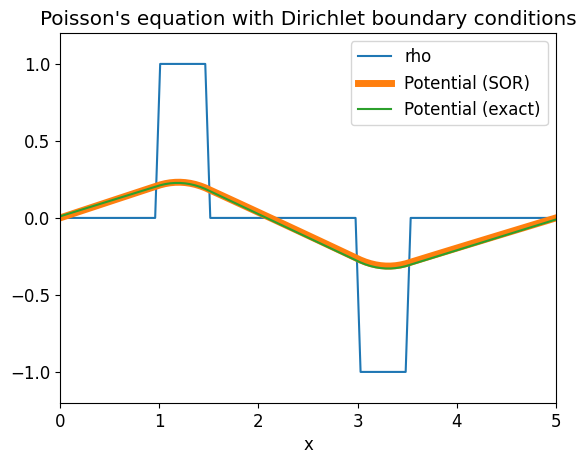

In [ ]:
tolerance = 1.0e-4
max_iter = 3000
omega = 1.0
do_poisson_dirichlet_SOR_compiled_test(tolerance, max_iter, omega)

Were you expecting this result? Poisson is satisfied: the potential is parabolic where the charge is located (with the right sign of the second derivative) and linear in the regions where there is no charge. However, physically, this system is a capacitor, so why there is an electric field **outside** of the capacitor ($E_x = - \dfrac{\partial \phi}{\partial x}$)?

# Exercise 6: solve 1D Poisson's equation with Neumann boundary conditions using the SOR method
Let's solve the same problem of exercise 5, but this time with Neumann boundary conditions:

$\dfrac{\partial \phi}{\partial x}(0) = \dfrac{\partial \phi}{\partial x}(5) = 0$

which correspond to zero electric field at the boundaries.

How can we impose Neumann boundary conditions? We can set $\phi_0$ and $\phi_{N-1}$ in such a way that the (second-order accurate) finite difference approximation of the first order derivatives at $\phi_0$ and $\phi_{N-1}$ have the values dictated by the Neumann boundary conditions. If we have a look [here](https://en.wikipedia.org/wiki/Finite_difference_coefficient) we can see that the right expressions for the (second order accurate) forward and the backward finite differences approximations of the first order derivative are:

- Forward:  $\dfrac{\partial f}{\partial x} (x_i) \approx \dfrac{- 3 f(x_i) + 4 f(x_{i+1}) - f(x_{i+2})}{2 \Delta x} $

- Backward: $\dfrac{\partial f}{\partial x} (x_i) \approx \dfrac{  3 f(x_i) - 4 f(x_{i-1}) + f(x_{i-2})}{2 \Delta x} $

Use this information to complete the code in `poisson_neumann_SOR_compiled` and run the code blocks below to check the result.

In [ ]:
@nb.jit
def poisson_neumann_SOR_compiled (rho, phi0, dx, neumann_boundary, tolerance, max_iter, omega):
    """
    This method is a Poisson's solver based on the Successive Over Relaxation (SOR) method
    and enforcing Neumann boundary conditions. It accepts as an input the charge density rho,
    an initial guess for the potential phi0, the step size dx and the Neumann boundary
    conditions neumann_boundary. The method stops if tolerance is met or if the max_iter
    number of iterations is attained.The user has to pass the omega parameter as an argument.

    Parameters
    ----------
    rho : array of floats
        N-components vector of the density rho. Note that rho[0] and rho[N-1] will be ignored by the algorithm.
    phi0 : array of floats
        N-components vector, initial guess of the potential
    dx : float
        spatial step size
    neumann_boundary : array of floats
        2-components array storing the Neumann boundary conditions
    tolerance : float
        maximum accepted value of the residual norm
    max_iter : integer
        maximum number of iterations
    omega : float
        the omega parameter used in the SOR method

    Returns
    -------
    phi : array of floats
        the computed potential
    it : integer
        the number of iterations required to compute the potential
    """

    N = np.shape(phi0)[0] # size of the vectors phi and rho

    phi = np.copy(phi0) # deep copy of the initial guess x0: we don't want to overwrite it!

    # residual R
    R = np.zeros(N)
    norm_R = 1.0

    for it in range(max_iter):

        # enforce boundary conditions for phi[0]
        #### YOUR CODE HERE ###
        phi[0] = 0.0
        ########################

        #### SOLUTION ##########
        phi[0] = (-2 * neumann_boundary[0] * dx + 4*phi[1] -  phi[2])/3.0
        ########################

        #### YOUR CODE HERE ###
        for i in range(1,N-1):
            #phi[i] = ...
            pass

         # This block of code can be copied without
         # modifications from poisson_dirichlet_SOR_compiled

        ########################

        #### SOLUTION ###
        for i in range(1,N-1):
            phi[i] = (1.0-omega)*phi[i] + omega* (+rho[i]*(dx**2) + phi[i-1] + phi[i+1] )/2.0

        for i in range(1,N-1):
            R[i] = (phi[i-1] - 2*phi[i] + phi[i+1]) + rho[i]*(dx**2)

        norm_R = np.linalg.norm(R)
        ##################

        # enforce boundary conditions for phi[N-1]
        #### YOUR CODE HERE ###
        phi[N-1] = 0.0
        ########################

        #### SOLUTION ##########
        phi[N-1] = (2 * neumann_boundary[0] * dx - 4*phi[N-2] +  phi[N-3])/3.0
        ########################

        if (norm_R < tolerance):
            return phi, it

    raise RuntimeError("Solver failed to converge!")

    return phi, -1

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def do_poisson_neumann_SOR_compiled_test(tolerance, max_iter, omega):
    """
    Test the poisson_neumann_SOR_compiled method

    Parameters
    ----------
    tolerance : float
        maximum accepted value of the residual norm
    max_iter : integer
        maximum number of iterations
    omega : float
        the omega parameter used in the SOR method
    """

    # Define the points where we want to solve our system
    N = 100
    L = 5
    x = np.linspace(0, L, N)
    dx = L/(N-1)
    ##################

    # Compute the charge density
    x0 = 1
    x1 = 1.5
    x2 = 3
    x3 = 3.5
    rho = (x > x0)*(x < x1) * 1.0 - (x > x2)*(x < x3) * 1.0
    ##################

    # Set the boundary conditions
    neumann_boundary = np.array([0.0, 0.0])
    ##################

    # Compute the matrix A to check result with exact solver
    A = np.zeros([N,N])
    A[0,0] = -1.5/dx
    A[0,1] = 2.0/dx
    A[0,2] = -0.5/dx
    for i in range(1,N-1):
        A[i,i-1] = 1
        A[i,i] = -2
        A[i,i+1] = 1
    A[N-1,N-3] = 0.5/dx
    A[N-1,N-2] = -2/dx
    A[N-1,N-1] = 1.5/dx
    ##################

    # Compute b
    phi_left = 0.0
    phi_right = 0.0
    b = np.zeros(N)
    b[0] = neumann_boundary[0]
    b[1:-1] = -rho[1:-1]*(dx)**2
    b[-1] = neumann_boundary[1]
    ##################

    plt.plot(x, rho, label="rho")

    phi_0 = np.zeros(N)
    phi, it = poisson_neumann_SOR_compiled (rho, phi_0, dx, neumann_boundary, tolerance, max_iter, omega)
    print("Solver converged at iteration: {:d}".format(it))
    phi_ex = np.linalg.solve (A, b)

    plt.title("Poisson's equation with Neumann boundary conditions")

    plt.plot(x, phi, label="Potential (SOR)", linewidth=5)
    plt.plot(x, phi_ex, label="Potential (exact)")

    plt.xlim(0,L)
    plt.ylim(-1.2,1.2)

    plt.xlabel("x")
    plt.legend()

Feel free to experiment with different values of `max_iter`, `tolerance` and `omega`

Solver converged at iteration: 13397


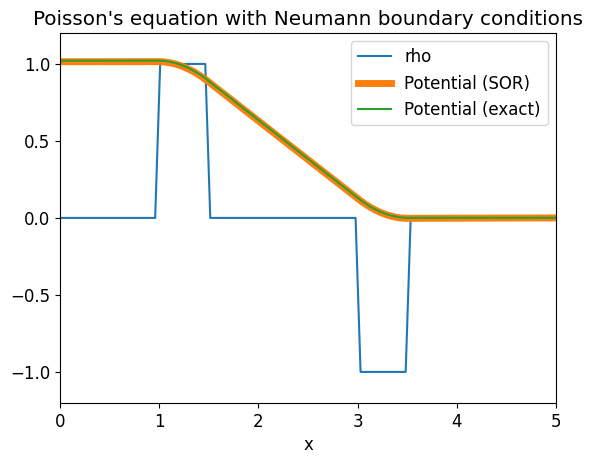

In [ ]:
tolerance = 1.0e-5
max_iter = 15000
omega = 1.2
do_poisson_neumann_SOR_compiled_test(tolerance, max_iter, omega)

# Exercise 7: solve 2D Poisson's equation using an FFT-based solver

In this exercise we will use the Fast Fourier Transform to solve Poisson's equation (note that we have dropped $\epsilon_0$ to simplify the equation, which can be done by choosing an opportune system of units):

$  \nabla^2 \phi(\mathbf{x})  = - \rho(\mathbf{x}) $

In Fourier space, the Poisson's equation is extremely simple:

$ \hat{\phi}(\mathbf{k})  = \dfrac{\hat{\rho}(\mathbf{k})}{k^2} $

Complete the few missing lines of the code below to make it work!

Note that with an FFT-based solver we can only impose periodic boundary conditions.

/tmp/ipykernel_12440/2730799535.py:45: RuntimeWarning: invalid value encountered in divide
  phi_hat = rho_hat/K2


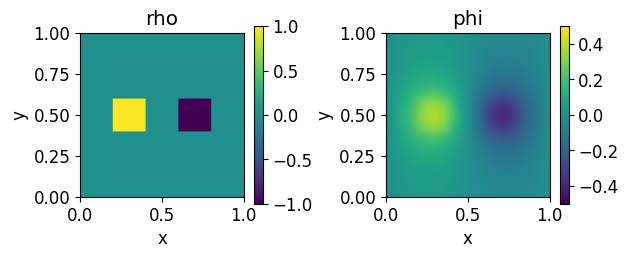

In [ ]:
def do_poisson_2D_fft_test ():
    """
    Test a 2D Poisson solver based on FFT
    """

    #define the geometry of our problem
    Nx = 1000
    Ny = 1000
    Lx = 1.0
    Ly = 1.0

    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    dx = Lx/(Nx-1)
    dy = Ly/(Ny-1)

    X, Y = np.meshgrid(x, y) # X and Y are 2D
    ###################################

    # define the charge density (two squares of opposite charge)
    rho = ((X > Lx/5)*(X < 2*Lx/5)*1.0 - (X > 3*Lx/5)*(X < 4*Lx/5)*1.0)*(Y > 2*Ly/5)*(Y < 3*Ly/5)
    ###################################

    # compute the Fourier transform of the charge density rho and the K vector
    rho_hat = np.fft.fft2(rho)

    k_x = np.fft.fftfreq(Nx, d=dx)
    k_y = np.fft.fftfreq(Ny, d=dy)
    KX, KY = np.meshgrid(k_x, k_y)
    ###################################

    ############# YOUR CODE HERE! #####

    phi_hat = np.zeros([Nx,Ny])
    #phi_hat = ...

    # We may need to take care of one NaN value (why?).
    # We can take care of that with the following function:
    # np.nan_to_num(phi_hat, copy=False, nan=0.0)
    # which is equivalent to saying that the system is globally neutral (why?)
    ###################################

    ############# SOLUTION ############
    K2 = KX**2 + KY**2
    phi_hat = rho_hat/K2
    np.nan_to_num(phi_hat, copy=False, nan=0.0)
    ###################################

    phi = np.fft.ifft2(phi_hat)

    fig, ax = plt.subplots(1,2)

    p0 = ax[0].imshow(rho, vmin=-1, vmax=1, extent=[0, Lx, 0, Ly])
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    ax[0].set_title("rho")
    fig.colorbar(p0, ax=ax[0],shrink=0.4)

    p1 = ax[1].imshow(np.real(phi), vmin=-0.5, vmax=0.5, extent=[0, Lx, 0, Ly])
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("y")
    ax[1].set_title("phi")
    fig.colorbar(p1, ax=ax[1],shrink=0.4)


    plt.tight_layout()

do_poisson_2D_fft_test ()

# Exercise 8 [for home or in class if we have time] : a 2D Poisson solver with Dirichlet boundary conditions using SOR

Can you implement a 2D Poisson solver using the SOR method to solve, for instance, a problem similar to that of exercise 7 but with Dirichlet boundary conditions $\phi = 0$ on the border?